**Goal:** quantify a relationship in the penguins data three ways -- Pearson's r, the
same r built from L18's dot product, and a best-fit line that predicts -- then read the
whole correlation matrix and catch a real Simpson's paradox in the act. Pairs with the
concept note
[Relationships Between Two Variables: Correlation](l19_concept_correlation.qmd).

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/devomh/cdat4001-2026/blob/main/u05_visualization/l19_lab_correlation.ipynb)

> This page is the read-only view. To run the lab, open the notebook
> (`l19_lab_correlation.ipynb`) -- in Colab via the badge above, or locally. Every text
> output below comes from actually running the cells.

## Prerequisites & Setup

**Palmer Penguins** (Gorman, Williams & Fraser 2014, *PLoS ONE*; CC0 public domain), 344
penguins -- the same dataset you explored in Unit III, so you already know its columns and
its missing values. No random numbers in this lab, so there is nothing to seed.

In [1]:
# Setup cell 1 of 2: install only (Colab resets on open; run this first)
%pip install -q pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup cell 2 of 2: imports + load the penguins (bundled, with a live fallback)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Palmer Penguins -- Gorman, Williams & Fraser (2014), PLoS ONE; CC0 public domain
LOCAL = "data/penguins.csv"
URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
penguins = pd.read_csv(LOCAL if os.path.exists(LOCAL) else URL)
print(penguins.shape)

(344, 7)


<details><summary>Expected Output</summary>

~~~text
(344, 7)
~~~
</details>

## Step 1: One Relationship -- Scatter + r (Worked)

Flipper length vs body mass: the scatter is the L09 read (direction, form, strength,
unusual points), then the number.

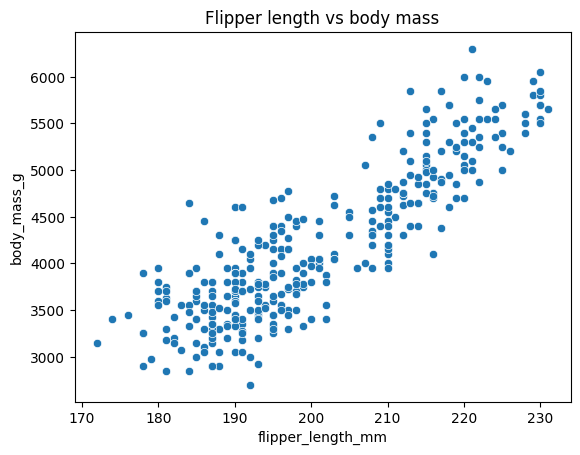

Pearson r = +0.87


In [3]:
sns.scatterplot(data=penguins, x="flipper_length_mm", y="body_mass_g")
plt.title("Flipper length vs body mass")
plt.show()

r = penguins["flipper_length_mm"].corr(penguins["body_mass_g"])
print(f"Pearson r = {r:+.2f}")

<details><summary>Expected Output</summary>

~~~text
Pearson r = +0.87
~~~
</details>

> **Read it:** direction positive (longer flippers, heavier birds), form roughly linear,
> strength high -- the cloud is tight, no isolated stragglers. The number agrees: +0.87,
> strong positive. (pandas quietly skipped the rows with missing values.)

A cheap insurance check the concept note insisted on -- color the same scatter by species,
to make sure no subgroup is hiding:

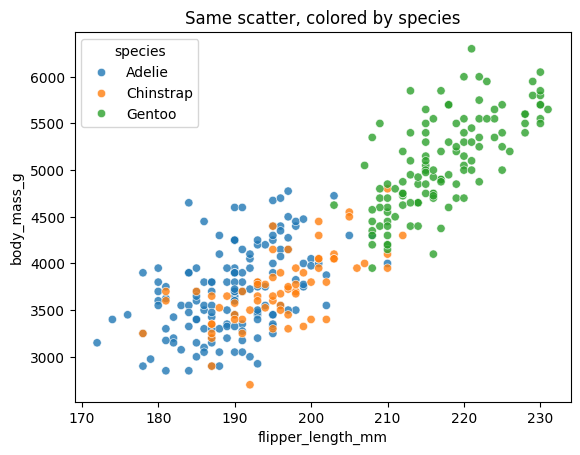

In [4]:
sns.scatterplot(data=penguins, x="flipper_length_mm", y="body_mass_g",
                hue="species", alpha=0.8)
plt.title("Same scatter, colored by species")
plt.show()

> **Read it:** three clouds -- Gentoo up-right (bigger on both axes), Adelie and Chinstrap
> overlapping lower-left. The positive trend points the same way *inside* each cloud, so
> here the pooled number is honest. Remember this check; in Step 4 it saves us from a wrong
> conclusion.

## Step 2: The Same r, Built from L18 (Worked)

The concept note's claim: Pearson's r is L18's **cosine of the two mean-centered columns**,
and covariance is their **dot product**. Build it by hand and check it against pandas.

In [5]:
pair = penguins[["flipper_length_mm", "body_mass_g"]].dropna()
x = pair["flipper_length_mm"].to_numpy()
y = pair["body_mass_g"].to_numpy()

xc = x - x.mean()            # center each column (subtract its mean)
yc = y - y.mean()
covariance = (xc @ yc) / (len(x) - 1)                       # L18 dot product, averaged
r_cosine = (xc @ yc) / (np.linalg.norm(xc) * np.linalg.norm(yc))   # L18 cosine

print(f"rows after dropna: {len(x)}")
print(f"covariance (xc @ yc / n-1): {covariance:,.1f}")
print(f"r via L18 cosine:  {r_cosine:+.6f}")
print(f"r via pandas corr: {pair['flipper_length_mm'].corr(pair['body_mass_g']):+.6f}")
print(f"match: {np.isclose(r_cosine, pair['flipper_length_mm'].corr(pair['body_mass_g']))}")

rows after dropna: 342
covariance (xc @ yc / n-1): 9,824.4
r via L18 cosine:  +0.871202
r via pandas corr: +0.871202
match: True


<details><summary>Expected Output</summary>

~~~text
rows after dropna: 342
covariance (xc @ yc / n-1): 9,824.4
r via L18 cosine:  +0.871202
r via pandas corr: +0.871202
match: True
~~~
</details>

> **Read it:** identical to six decimals. Correlation is not new machinery -- it is L18's
> dot product (covariance) turned into L18's cosine (r) by dividing out the two vectors'
> lengths. Centering first is the only twist: it makes "above/below the mean", not
> "big/small", the thing being compared.

## Step 3: Correlation as a Predictive Tool (Worked + Completion)

If two variables correlate, a straight line can **predict** one from the other.
`np.polyfit(x, y, 1)` returns the best line's slope and intercept:

slope = 49.7 g per mm, intercept = -5780.8 g
predicted mass at flipper=210mm: 4,653 g
r-squared = 0.759


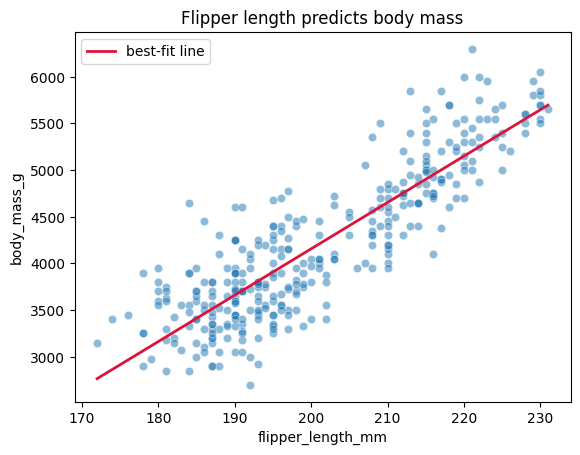

In [6]:
slope, intercept = np.polyfit(x, y, 1)
print(f"slope = {slope:.1f} g per mm, intercept = {intercept:.1f} g")
print(f"predicted mass at flipper=210mm: {slope*210 + intercept:,.0f} g")
print(f"r-squared = {r**2:.3f}")

sns.scatterplot(data=penguins, x="flipper_length_mm", y="body_mass_g", alpha=0.5)
xs = np.array([penguins['flipper_length_mm'].min(), penguins['flipper_length_mm'].max()])
plt.plot(xs, slope*xs + intercept, color="crimson", linewidth=2, label="best-fit line")
plt.legend(); plt.title("Flipper length predicts body mass")
plt.show()

<details><summary>Expected Output</summary>

~~~text
slope = 49.7 g per mm, intercept = -5780.8 g
predicted mass at flipper=210mm: 4,653 g
r-squared = 0.759
~~~
</details>

> **Read it:** the line predicts about 50 g of body mass per extra millimetre of flipper,
> and **r-squared = 0.76** says it accounts for about three-quarters of the variation in
> mass -- a strong predictor, with a quarter left to everything else. A higher |r| would
> mean a tighter cloud and a better line.

Your turn -- predict the mass of a penguin with a 200 mm flipper.

In [7]:
# Uncomment and fill the ____ : reuse slope and intercept from above.
# print(f"predicted mass at flipper=200mm: {slope*____ + intercept:,.0f} g")

<details><summary>Expected Output</summary>

~~~text
predicted mass at flipper=200mm: 4,156 g
~~~
*(200 mm is inside the observed flipper range, so the line is trustworthy here. Predict at
300 mm and you would have hope, not evidence -- never extrapolate the fit past the data.)*
</details>

## Step 4: All Pairs, and a Paradox (Worked + Completion)

Six pairs of measurements is too many scatters to eyeball. Compute the full matrix:

In [8]:
numeric = penguins.select_dtypes("number")
print(numeric.corr().round(2).to_string())

                   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
bill_length_mm               1.00          -0.24               0.66         0.60
bill_depth_mm               -0.24           1.00              -0.58        -0.47
flipper_length_mm            0.66          -0.58               1.00         0.87
body_mass_g                  0.60          -0.47               0.87         1.00


<details><summary>Expected Output</summary>

~~~text
                   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
bill_length_mm               1.00          -0.24               0.66         0.60
bill_depth_mm               -0.24           1.00              -0.58        -0.47
flipper_length_mm            0.66          -0.58               1.00         0.87
body_mass_g                  0.60          -0.47               0.87         1.00
~~~
</details>

A heatmap makes the matrix scannable. **Uncomment and fill the two ____ blanks**: the
first is the matrix, the second turns on the in-cell numbers (True/False). Note the
colormap -- `coolwarm` is *diverging* because r has a meaningful midpoint at 0 (the L16
color principle).

In [9]:
# Uncomment and fill the two ____ blanks, then run:
# sns.heatmap(____, annot=____, cmap="coolwarm", vmin=-1, vmax=1)
# plt.title("Pearson correlation, penguin measurements")
# plt.show()

<details><summary>Expected Output</summary>

*(A 4x4 heatmap: deep-red diagonal of 1.00, warm red 0.87 for flipper/body-mass, and the
bill-depth row/column in blues -- including -0.47 against body mass. Cool colors where
everything "should" grow together is the anomaly worth chasing.)*
</details>

The bill-depth row is negative against everything, including **-0.47** with body mass.
Deeper bills on *lighter* penguins? Check it the way Step 1 taught -- overall, then within
each species:

In [10]:
pair_bd = ["bill_depth_mm", "body_mass_g"]
print(f"overall    r = {penguins[pair_bd[0]].corr(penguins[pair_bd[1]]):+.2f}")
for species, group in penguins.groupby("species"):
    print(f"{species:10s} r = {group[pair_bd[0]].corr(group[pair_bd[1]]):+.2f}")

overall    r = -0.47
Adelie     r = +0.58
Chinstrap  r = +0.60
Gentoo     r = +0.72


<details><summary>Expected Output</summary>

~~~text
overall    r = -0.47
Adelie     r = +0.58
Chinstrap  r = +0.60
Gentoo     r = +0.72
~~~
*(Pooled it is moderately NEGATIVE; inside every species it is POSITIVE. Both correct, and
they contradict each other -- Simpson's paradox in the wild.)*
</details>

> **Read it:** within any one species, deeper bill means heavier bird. But Gentoo (heavy)
> happens to have shallow bills, so its cloud sits high-left of the others; pool the
> species and the line through all three tilts *downward*. The lurking variable is species.
> Report the pooled -0.47 and you have described penguin taxonomy, not penguin anatomy.

## Your Turn (Exercises)

### Exercise 1 -- Group-check the strong one

Step 1's flipper/body-mass r was +0.87 pooled. Is it honest, or another paradox? Compute
the **per-species r** for flipper vs body mass (reuse Step 4's `groupby` loop with the
flipper/mass pair). One sentence: does the +0.87 survive the group check?

In [11]:
# TODO: your code here

<details><summary>Expected Output (one possible answer -- match the values, not the print format)</summary>

~~~text
Adelie     r = +0.47
Chinstrap  r = +0.64
Gentoo     r = +0.70
~~~
*(All positive -- weaker than the pooled +0.87 (part of that number was just "Gentoo is
big"), but the direction survives in every species. NOT a paradox this time: the group
check confirms the pooled story instead of reversing it.)*
</details>

### Exercise 2 -- Pearson vs Spearman

Compute both Pearson and Spearman correlation for flipper vs body mass, then for the toy
series `y = 2 ** x` (x from 1 to 10). One sentence: why do Pearson and Spearman nearly
agree for the penguins but disagree for the toy?

> **Hint:** `s1.corr(s2)` is Pearson; add `method="spearman"` for Spearman. Build the toy
> with `pd.Series(range(1, 11))` and `2.0 ** x`.

In [12]:
# TODO: your code here

<details><summary>Expected Output (one possible answer -- match the values, not the print format)</summary>

~~~text
flipper-mass Pearson  = +0.87
flipper-mass Spearman = +0.84
toy 2**x Pearson  = 0.80
toy 2**x Spearman = 1.00
~~~
*(For the penguins the relationship is roughly linear, so the two measures nearly agree.
The toy doubles every step -- perfectly monotone but strongly curved -- so Spearman (on
ranks) reads a perfect 1.00 while Pearson docks it to 0.80 for not being straight. Spearman
earns its keep exactly when the relationship is monotone but not linear.)*
</details>

### Exercise 3 -- Name the Confounder

Ice-cream sales correlate strongly with drowning deaths, month by month. In two or three
sentences: name the confounder, explain the mechanism, and give the analogous statement
for the bill-depth paradox of Step 4 (what plays the role of "summer", and what would
"banning ice cream" correspond to?).

<details><summary>One acceptable answer</summary>

The confounder is summer: hot weather independently raises both ice-cream sales and
swimming (hence drownings); neither causes the other. In Step 4 the role of summer is
played by species -- being a Gentoo independently makes a penguin heavier AND
shallower-billed, manufacturing the pooled negative correlation. "Banning ice cream to
prevent drownings" corresponds to filing down bills to fatten penguins: intervening on a
variable that never caused the outcome.
</details>

## Summary

| Move | Key commands | What you learned |
|------|-------------|------------------|
| Quantify a relationship | `x.corr(y)` | Pearson r = +0.87 for flipper vs body mass |
| Build r from L18 | `xc @ yc / (norm(xc)*norm(yc))` | r IS the cosine of the mean-centered columns (=0.871202) |
| Predict with it | `np.polyfit(x, y, 1)`; r-squared | the best-fit line; r-squared = 0.76 of variance explained |
| Scale to all pairs | `df.corr()` + diverging heatmap | -0.47 bill-depth/mass is the lead to chase |
| Group-check it | `groupby` + per-group r | Simpson's paradox: -0.47 pooled, positive within every species |

Next lesson (L20): when there are too many variables for pairwise r, **PCA** projects them
down to a 2-D picture -- using L18's projection, the same dot product once more.